# 14 — Caractérisation du reliquat non classé

**Constat de départ (notebook 13, Q1)** — les règles de `texte.classer()`
laissent 46 % des tickets du Système A en `non_classe`. Ce notebook répond à
une question de méthode : **faut-il chercher à classer ce reliquat, et si oui
comment ?**

**Ce que ce notebook établit** — la réponse est *non*, et pour une raison
mesurable plutôt que par renoncement :

1. la voie « classifieur supervisé entraîné sur les paires A↔B » est une
   **impasse démontrable** — le test du §1 le prouve sur des tickets dont la
   cause est connue ;
2. le reliquat n'est pas du transactionnel mal formulé, c'est **un autre
   domaine** que la taxonomie n'a jamais couvert (§2 et §3) ;
3. étendre les règles rapporte peu, et le §4 chiffre ce rendement décroissant
   annoncé par `texte.py` ;
4. surtout, **le reliquat ne peut pas renverser la conclusion métier** du
   notebook 13 (§5) — ce qui rend l'effort inutile pour la direction.

> **Note de révision.** Une version antérieure de ce notebook appliquait un
> classifieur TF-IDF + régression logistique au reliquat et concluait à une
> requalification de 43 % de celui-ci (46 % → 26 % de non classés). Le §1
> ci-dessous montre que ce résultat était un **artefact de monde fermé** : le
> modèle, n'ayant que six classes transactionnelles, était contraint
> d'étiqueter des tickets hors de son espace. Cette conclusion est retirée.
> Le classifieur reste construit ici, mais comme **instrument de diagnostic**,
> pas comme producteur d'étiquettes.

| | |
|---|---|
| **Entrée** | Système A classifié (notebook 13 setup), appariement A↔B (notebook 09), sous-motifs B (notebook 08) |
| **Sorties** | `resultats/tables/14_*.csv` + `resultats/figures/14_*.png` |

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent
sys.path.insert(0, str(RACINE / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from reclamations import chargement, config, consolidation, systeme_b, texte, topics, viz

viz.appliquer_charte()
pd.set_option("display.width", 160)

# --- Système A : périmètre opérationnel complet + classification causale ---
df_a = chargement.typer(chargement.charger_brut())
tickets_a = chargement.perimetre_operationnel(df_a).copy()
messages = chargement.charger_messages_ouverture()
tickets_a["texte"] = chargement.construire_texte_enrichi(tickets_a, messages)
tickets_a["a_texte"] = texte.a_texte_exploitable(tickets_a["texte"])
tickets_a["famille"] = texte.classer(tickets_a["texte"])
tickets_a["texte_masque"] = tickets_a["texte"].map(texte.masquer_identifiants)

# Base d'analyse : tickets dont le texte est exploitable (seuls classables).
base = tickets_a[tickets_a["a_texte"]].copy()
reliquat = base[base["famille"] == texte.NON_CLASSE].copy()

print(f"Système A (période opérationnelle)  : {len(tickets_a):,}")
print(f"Base texte exploitable              : {len(base):,}")
print(f"  dont reliquat non_classe          : {len(reliquat):,} ({len(reliquat) / len(base):.1%})")

/home/gauss/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)
/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)
/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)
/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


Système A (période opérationnelle)  : 18,056
Base texte exploitable              : 10,354
  dont reliquat non_classe          : 4,759 (46.0%)


## 1. Pourquoi la classification apprise sur les paires A↔B est une impasse

L'idée testée dans la version antérieure était séduisante : les tickets
appariés A↔B (notebook 09) portent un sous-motif **annoté à la main** côté B,
donc un jeu d'entraînement gratuit. On le reconstruit ici à l'identique.

Le point aveugle est l'**espace d'étiquettes**. Seuls six sous-motifs B ont
assez d'exemples pour être appris, et tous les six sont transactionnels
(Cash-In, Cash-Out, Wallet-to-Wallet…). Un classifieur `predict_proba` est un
modèle de **monde fermé** : confronté à un ticket dont la vraie cause n'existe
pas dans ses six classes, il ne peut pas répondre « aucune » — il répartit sa
probabilité sur les six et en désigne une.

In [2]:
# --- Reconstruction du jeu de référence (identique au notebook 13 Q8) ---
tickets_b_brut = systeme_b.charger_tickets()
champs_b, valeurs_b = systeme_b.charger_champs_personnalises()
sous_motifs_b = systeme_b.sous_motifs(champs_b, valeurs_b)

paires = consolidation.apparier(
    consolidation.cles_a(tickets_a),
    consolidation.cles_b(tickets_b_brut, champs_b, valeurs_b),
)

idx_a = tickets_a.set_index("id")
jeu = paires[["ticket_id_a", "ticket_id_b"]].copy()
for colonne in ["texte_masque", "a_texte", "famille", "ticket_type_name"]:
    jeu[colonne] = jeu["ticket_id_a"].map(idx_a[colonne])
jeu = (
    jeu.merge(sous_motifs_b[["sous_motif"]], left_on="ticket_id_b", right_index=True, how="inner")
       .drop_duplicates(["ticket_id_a", "ticket_id_b"])
)
jeu = jeu[jeu["a_texte"] == True].drop_duplicates("ticket_id_a")

SEUIL_MIN_CLASSE = 20
effectifs = jeu["sous_motif"].value_counts()
classes_retenues = effectifs[effectifs >= SEUIL_MIN_CLASSE].index
entrainement = jeu[jeu["sous_motif"].isin(classes_retenues)].copy()

GRAINE = 42
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(min_df=2, max_df=0.6, ngram_range=(1, 2),
                              stop_words=list(topics.MOTS_VIDES))),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=GRAINE)),
])
pipeline.fit(entrainement["texte_masque"], entrainement["sous_motif"])

print(f"Jeu de référence      : {len(jeu):,} tickets, {jeu['sous_motif'].nunique()} sous-motifs")
print(f"Classes apprises      : {len(classes_retenues)} (>= {SEUIL_MIN_CLASSE} exemples)")
print(f"  -> {', '.join(sorted(classes_retenues))}")
print(f"Tickets d'entraînement : {len(entrainement):,}")

Jeu de référence      : 950 tickets, 13 sous-motifs
Classes apprises      : 6 (>= 20 exemples)
  -> Bénéficiaire erroné, Fond non perçu, Échec Cash-In, Échec Cash-Out, Échec Wallet-to-Other-Wallet, Échec Wallet-to-Wallet
Tickets d'entraînement : 922


### 1.1 Le test décisif

Plutôt que d'évaluer le modèle sur son propre jeu (validation croisée — qui
lui donnait 76 % d'exactitude et validait à tort la démarche), on l'applique
aux tickets **dont les règles ont déjà identifié la cause**. C'est une
référence indépendante et gratuite : si un ticket dit « mon OTP ne
fonctionne pas », toute prédiction transactionnelle est fausse par
construction.

In [3]:
# Tickets appariés dont une règle A a identifié la cause : la vérité est connue.
verif = jeu[jeu["famille"] != texte.NON_CLASSE].copy()
proba_verif = pipeline.predict_proba(verif["texte_masque"])
verif["predit"] = pipeline.named_steps["clf"].classes_[proba_verif.argmax(axis=1)]
verif["confiance"] = proba_verif.max(axis=1)

diagnostic = (
    pd.crosstab(verif["famille"], verif["predit"], normalize="index")
      .mul(100).round(1)
)
diagnostic.index = diagnostic.index.map(texte.libelles())
chargement.sauver_table(diagnostic, "14_diagnostic_hors_domaine")

print("Prédiction du classifieur (%) selon la famille causale établie par les règles :")
diagnostic

  -> resultats/tables/14_diagnostic_hors_domaine.csv
Prédiction du classifieur (%) selon la famille causale établie par les règles :


predit,Bénéficiaire erroné,Fond non perçu,Échec Cash-In,Échec Cash-Out,Échec Wallet-to-Other-Wallet,Échec Wallet-to-Wallet
famille,,,,,,
Accès bloqué / OTP / authentification,3.6,0.0,96.4,0.0,0.0,0.0
Carte bancaire / distributeur,0.0,0.0,100.0,0.0,0.0,0.0
"Débit injustifié, doublé, ou frais contestés",3.8,0.0,84.6,11.5,0.0,0.0
Débité sans que le bénéficiaire soit crédité,1.5,5.7,33.9,3.0,48.8,7.1
Demande d'information (pas une réclamation),33.3,0.0,33.3,0.0,33.3,0.0
Erreur de saisie du client (mauvais bénéficiaire),95.8,1.6,2.6,0.0,0.0,0.0


Le résultat est sans appel. Les familles `acces_otp` (authentification) et
`carte` (monétique) n'ont **aucun équivalent** dans les six sous-motifs
appris : le modèle les déverse quasi intégralement dans sa classe la plus
volumineuse, « Échec Cash-In ». Un blocage d'OTP n'est pas un échec de
Cash-In.

À l'inverse — et c'est ce qui rend le diagnostic précis plutôt
qu'accablant — le modèle est **juste là où il peut l'être** :
`erreur_client` part vers « Bénéficiaire erroné », `debit_non_credit` se
répartit entre les sous-motifs d'échec de transfert. Le modèle n'est pas
mauvais : il est **appliqué hors de son domaine**.

On sépare donc les deux populations pour mesurer chacune séparément.

In [4]:
# Familles A qui ont un équivalent réel dans l'espace de sortie B.
# En dehors de cette correspondance, le modèle ne PEUT PAS avoir raison.
EQUIVALENCES = {
    "debit_non_credit": {"Échec Cash-In", "Échec Cash-Out", "Échec Wallet-to-Wallet",
                         "Échec Wallet-to-Other-Wallet", "Fond non perçu"},
    "erreur_client": {"Bénéficiaire erroné"},
}

dans_domaine = verif[verif["famille"].isin(EQUIVALENCES)].copy()
dans_domaine["coherent"] = [
    p in EQUIVALENCES[f] for p, f in zip(dans_domaine["predit"], dans_domaine["famille"])
]
hors_domaine = verif[~verif["famille"].isin(EQUIVALENCES)]

SEUILS = [0.45, 0.55, 0.65, 0.75]
lignes = []
for seuil in SEUILS:
    garde_dans = dans_domaine["confiance"] >= seuil
    garde_hors = hors_domaine["confiance"] >= seuil
    lignes.append({
        "seuil": f"{seuil:.0%}",
        "dans_domaine_retenus": int(garde_dans.sum()),
        "dans_domaine_coherence_pct": round(dans_domaine.loc[garde_dans, "coherent"].mean() * 100, 1)
        if garde_dans.any() else np.nan,
        "hors_domaine_etiquetes": int(garde_hors.sum()),
        "hors_domaine_faux_positifs_pct": round(garde_hors.mean() * 100, 1),
    })
fiabilite = pd.DataFrame(lignes).set_index("seuil")
chargement.sauver_table(fiabilite, "14_fiabilite_par_domaine")

print(f"Dans le domaine (familles {sorted(EQUIVALENCES)}) : {len(dans_domaine):,} tickets")
print(f"Hors domaine (acces_otp, carte, debit_injustifie, demande_info) : {len(hors_domaine):,} tickets")
print()
fiabilite

  -> resultats/tables/14_fiabilite_par_domaine.csv
Dans le domaine (familles ['debit_non_credit', 'erreur_client']) : 527 tickets
Hors domaine (acces_otp, carte, debit_injustifie, demande_info) : 61 tickets



,dans_domaine_retenus,dans_domaine_coherence_pct,hors_domaine_etiquetes,hors_domaine_faux_positifs_pct
seuil,,,,
45%,370,98.6,48,78.7
55%,260,98.1,25,41.0
65%,145,97.9,5,8.2
75%,66,100.0,0,0.0


**Lecture.** Dans son domaine, le modèle est excellent : ~99 % de cohérence
avec les règles, et cette valeur ne bouge pas avec le seuil. Hors domaine, au
seuil de 45 % retenu par la version antérieure, **près de 4 tickets sur 5
reçoivent une étiquette qui ne peut être que fausse**.

Le seuil de confiance était censé être le garde-fou. Il ne jouait pas ce
rôle : la confiance médiane du modèle sur le reliquat est d'environ 0,43,
c'est-à-dire que le seuil de 0,45 était posé **au milieu du bruit**. C'est
pourquoi 43 % du reliquat se retrouvait « requalifié », dont 80 % dans une
seule classe.

  -> resultats/figures/14_fiabilite_par_domaine.png


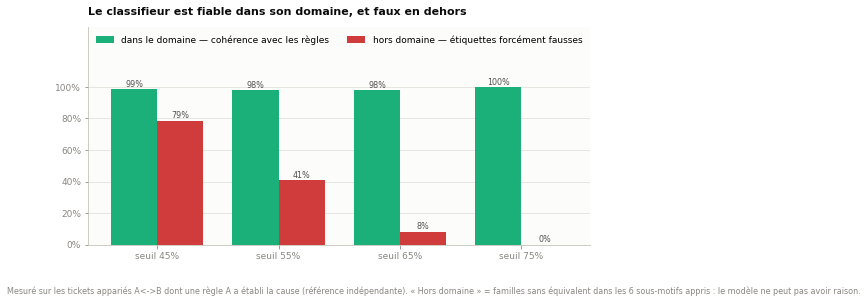

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(fiabilite))
largeur = 0.38
ax.bar(x - largeur / 2, fiabilite["dans_domaine_coherence_pct"], width=largeur,
       label="dans le domaine — cohérence avec les règles", color=viz.SERIES[2])
ax.bar(x + largeur / 2, fiabilite["hors_domaine_faux_positifs_pct"], width=largeur,
       label="hors domaine — étiquettes forcément fausses", color=viz.STATUT["critique"])
for i, (bon, mauvais) in enumerate(zip(fiabilite["dans_domaine_coherence_pct"],
                                       fiabilite["hors_domaine_faux_positifs_pct"])):
    ax.text(i - largeur / 2, bon + 1.5, f"{bon:.0f}%", ha="center", fontsize=8,
            color=viz.ENCRE["secondaire"])
    ax.text(i + largeur / 2, mauvais + 1.5, f"{mauvais:.0f}%", ha="center", fontsize=8,
            color=viz.ENCRE["secondaire"])
ax.set_xticks(x)
ax.set_xticklabels([f"seuil {s}" for s in fiabilite.index])
ax.set_ylim(0, 138)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=100, decimals=0))
ax.set_title("Le classifieur est fiable dans son domaine, et faux en dehors")
# Légende logée dans la marge haute libérée : les barres plafonnent à 100 %.
ax.legend(frameon=False, fontsize=9, loc="upper center", ncol=2)
ax.grid(axis="x", visible=False)
viz.annoter_source(
    fig,
    "Mesuré sur les tickets appariés A<->B dont une règle A a établi la cause (référence indépendante). "
    "« Hors domaine » = familles sans équivalent dans les 6 sous-motifs appris : le modèle ne peut pas avoir raison.",
)
viz.sauver(fig, "14_fiabilite_par_domaine")
plt.show()

## 2. Le reliquat n'est pas le même monde que le jeu d'entraînement

Le §1 montre que tout dépend de la proportion du reliquat qui relève du
domaine transactionnel. On la mesure avec la seule variable structurelle
disponible, `ticket_type_name` — une nomenclature de produit, indépendante du
texte, donc non circulaire.

In [6]:
composition = pd.DataFrame({
    "jeu_entrainement_pct": entrainement["ticket_type_name"].value_counts(normalize=True) * 100,
    "reliquat_pct": reliquat["ticket_type_name"].value_counts(normalize=True) * 100,
}).fillna(0).round(1)
composition["ecart_pt"] = (composition["reliquat_pct"] - composition["jeu_entrainement_pct"]).round(1)
composition = composition.sort_values("reliquat_pct", ascending=False)
chargement.sauver_table(composition, "14_composition_reliquat")

composition.head(10)

  -> resultats/tables/14_composition_reliquat.csv


,jeu_entrainement_pct,reliquat_pct,ecart_pt
ticket_type_name,,,
SARA,63.3,51.4,-11.9
COMPTE,14.2,36.1,21.9
BENEFICIAIRE ERRONE,22.3,4.4,-17.9
ACCUEIL,0.0,2.1,2.1
CARTE,0.1,2.0,1.9
CREDIT,0.0,1.9,1.9
OPERATIONS_INTERNATIONALES,0.0,0.8,0.8
DECOUVERT,0.0,0.5,0.5
EFIRST,0.0,0.4,0.4


  -> resultats/figures/14_composition_reliquat.png


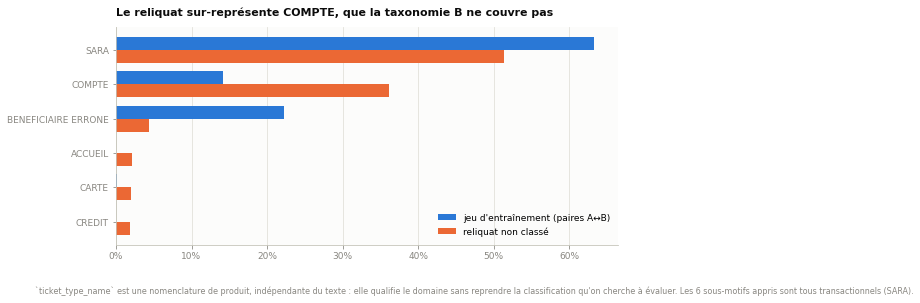

In [7]:
principales = composition.head(6).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(principales))
hauteur = 0.38
ax.barh(y + hauteur / 2, principales["jeu_entrainement_pct"], height=hauteur,
        label="jeu d'entraînement (paires A↔B)", color=viz.SERIES[0])
ax.barh(y - hauteur / 2, principales["reliquat_pct"], height=hauteur,
        label="reliquat non classé", color=viz.SERIES[1])
ax.set_yticks(y)
ax.set_yticklabels(principales.index, fontsize=9)
ax.set_title("Le reliquat sur-représente COMPTE, que la taxonomie B ne couvre pas")
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=100, decimals=0))
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.grid(axis="y", visible=False)
viz.annoter_source(
    fig,
    "`ticket_type_name` est une nomenclature de produit, indépendante du texte : elle qualifie le domaine "
    "sans reprendre la classification qu'on cherche à évaluer. Les 6 sous-motifs appris sont tous transactionnels (SARA).",
)
viz.sauver(fig, "14_composition_reliquat")
plt.show()

**Lecture.** `COMPTE` pèse environ deux fois et demie plus dans le reliquat
que dans le jeu d'entraînement, et des catégories entières (`ACCUEIL`,
`CARTE`, `CREDIT`, `OPERATIONS_INTERNATIONALES`…) y sont présentes alors
qu'elles sont **absentes** de l'entraînement. Enrichir le jeu de paires A↔B —
la « prochaine étape » que proposait la version antérieure de ce notebook — ne
corrigerait pas ce déséquilibre : il est structurel, la taxonomie B des
sous-motifs ne décrit que le transactionnel SARA.

## 3. Ce que contient réellement le reliquat

Puisque le reliquat n'est pas du transactionnel, de quoi parle-t-il ? On
compare le poids TF-IDF moyen de chaque terme entre le reliquat et les
tickets classés : les termes les plus **sur-représentés** dans le reliquat
décrivent ce que la taxonomie ne sait pas nommer.

  -> resultats/tables/14_termes_distinctifs_reliquat.csv


  -> resultats/figures/14_termes_distinctifs_reliquat.png


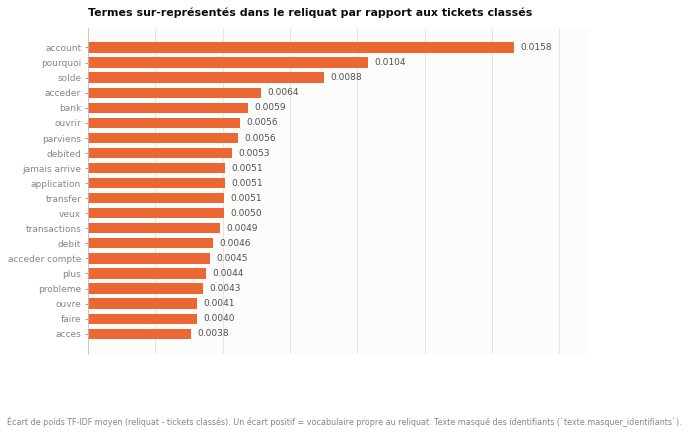

In [8]:
vectoriseur = TfidfVectorizer(min_df=20, max_df=0.5, ngram_range=(1, 2),
                              stop_words=list(topics.MOTS_VIDES))
matrice = vectoriseur.fit_transform(base["texte_masque"])
est_reliquat = (base["famille"] == texte.NON_CLASSE).to_numpy()

poids_reliquat = np.asarray(matrice[est_reliquat].mean(axis=0)).ravel()
poids_classes = np.asarray(matrice[~est_reliquat].mean(axis=0)).ravel()
termes = np.array(vectoriseur.get_feature_names_out())

surrepresentation = pd.Series(poids_reliquat - poids_classes, index=termes)
top = surrepresentation.sort_values(ascending=False).head(20)
tableau_termes = top.round(5).rename("surrepresentation").to_frame()
chargement.sauver_table(tableau_termes, "14_termes_distinctifs_reliquat")

fig, ax = plt.subplots(figsize=(9, 6))
viz.barres_horizontales(
    top, "Termes sur-représentés dans le reliquat par rapport aux tickets classés",
    ax=ax, format_valeur="{:.4f}", couleur=viz.SERIES[1],
)
viz.annoter_source(
    fig,
    "Écart de poids TF-IDF moyen (reliquat - tickets classés). Un écart positif = vocabulaire propre au reliquat. "
    "Texte masqué des identifiants (`texte.masquer_identifiants`).",
)
viz.sauver(fig, "14_termes_distinctifs_reliquat")
plt.show()

**Lecture.** Le vocabulaire propre au reliquat est cohérent et nommable :
`account`, `solde`, `acceder`, `acceder compte`, `balance`, `ouvrir`,
`epargne`, `parviens`, `application`. Ce n'est pas du bruit, ni un incident
transactionnel décrit autrement — c'est **l'accès au compte, la consultation
de solde et la gestion de compte**, croisé avec une forte présence de
l'anglais.

C'est le résultat principal de ce notebook : le reliquat n'est pas un échec
de classification, c'est **un pan de la relation client que la taxonomie
causale, construite autour de l'incident transactionnel, n'a jamais eu de
case pour recevoir**.

## 4. Combien une extension des règles récupérerait-elle ?

`texte.py` annonce un rendement décroissant pour l'ajout de motifs. Le §3
donne les thèmes à viser : on les code en familles candidates et on mesure ce
qu'elles récupèrent. Ces motifs sont **délibérément définis ici et non dans
`texte.FAMILLES`** : ce notebook les évalue, il ne les adopte pas — une
adoption changerait tous les chiffres des notebooks 04 à 13 et relève d'une
décision, pas d'une exécution.

In [9]:
CANDIDATES = {
    "Accès au compte / application": r"(n'?arrive pas a (me )?connect|impossible de (me )?connect"
        r"|acceder a mon compte|acces a mon compte|acceder au compte|n'?y parviens pas"
        r"|application ne (s'?)?ouvre|ne s'?ouvre pas|appli ne marche|bloque a la connexion"
        r"|can'?t (log|sign) in|cannot (log|sign) in|unable to (log|sign) in)",
    "Consultation de solde / historique": r"(mon solde|le solde|solde de mon compte|solde n'?est pas"
        r"|my balance|balance is|consulter mon solde|historique|releve|statement"
        r"|transactions? (n'?apparai|ne s'?affich)|n'?apparait pas dans)",
    "Ouverture / gestion de compte": r"(ouvrir un compte|ouverture de compte|open an account"
        r"|creer un compte|create an account|compte epargne|fermer mon compte"
        r"|changer (mon|de) numero|mettre a jour mes (informations|donnees))",
    "Demande de service (élargi)": r"(je (voudrais|veux|souhaite) savoir|comment (faire|puis-je)"
        r"|pourriez-vous m'?|j'?aimerais|how (do|can) i|i (would like|want) to know)",
}

reliquat["norme"] = reliquat["texte"].map(texte.normaliser)
reliquat["famille_candidate"] = ""
lignes = []
for nom, motif in CANDIDATES.items():
    correspond = reliquat["norme"].str.contains(motif, regex=True, na=False)
    nouveaux = correspond & (reliquat["famille_candidate"] == "")
    reliquat.loc[nouveaux, "famille_candidate"] = nom
    lignes.append({
        "famille_candidate": nom,
        "mentions": int(correspond.sum()),
        "captures_nettes": int(nouveaux.sum()),
        "pct_du_reliquat": round(nouveaux.sum() / len(reliquat) * 100, 1),
    })

rendement = pd.DataFrame(lignes).set_index("famille_candidate")
capte = int((reliquat["famille_candidate"] != "").sum())
couverture_avant = (base["famille"] != texte.NON_CLASSE).sum() / len(base)
couverture_apres = ((base["famille"] != texte.NON_CLASSE).sum() + capte) / len(base)
rendement.loc["TOTAL"] = [int(rendement["mentions"].sum()), capte,
                          round(capte / len(reliquat) * 100, 1)]
rendement[["mentions", "captures_nettes"]] = rendement[["mentions", "captures_nettes"]].astype(int)
chargement.sauver_table(rendement, "14_rendement_familles_candidates")

print(f"Reliquat capté par 4 familles candidates : {capte:,} / {len(reliquat):,} "
      f"({capte / len(reliquat):.1%})")
print(f"Couverture des règles   avant : {couverture_avant:.1%}")
print(f"Couverture des règles   après : {couverture_apres:.1%}  "
      f"(+{(couverture_apres - couverture_avant) * 100:.1f} points)")
print()
rendement

  -> resultats/tables/14_rendement_familles_candidates.csv
Reliquat capté par 4 familles candidates : 600 / 4,759 (12.6%)
Couverture des règles   avant : 54.0%
Couverture des règles   après : 59.8%  (+5.8 points)



/tmp/ipykernel_169160/3207093411.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = reliquat["norme"].str.contains(motif, regex=True, na=False)
/tmp/ipykernel_169160/3207093411.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = reliquat["norme"].str.contains(motif, regex=True, na=False)
/tmp/ipykernel_169160/3207093411.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = reliquat["norme"].str.contains(motif, regex=True, na=False)
/tmp/ipykernel_169160/3207093411.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = reliquat["norme"].str.contains(motif, regex=True, na=False)


,mentions,captures_nettes,pct_du_reliquat
famille_candidate,,,
Accès au compte / application,141,141,3.0
Consultation de solde / historique,293,290,6.1
Ouverture / gestion de compte,67,60,1.3
Demande de service (élargi),135,109,2.3
TOTAL,636,600,12.6


**Lecture.** Quatre familles nouvelles, ciblées sur les thèmes que le §3 a
fait remonter, ne récupèrent qu'environ un huitième du reliquat et font
gagner moins de six points de couverture. Le rendement décroissant annoncé
par `texte.py` est donc **confirmé et chiffré** : le reliquat est une vraie
longue traîne hétérogène, pas deux ou trois familles oubliées.

Ces familles restent intéressantes pour ce qu'elles **nomment** (§6), pas
pour le volume qu'elles ferment.

## 5. Le reliquat ne peut pas renverser la conclusion du notebook 13

C'est l'argument qui rend la question sans objet pour la direction. La
réponse à Q1 est un **classement** de familles causales, pas une répartition
exacte. On le soumet à trois hypothèses de plus en plus généreuses sur le
reliquat : si le classement survit même à la plus absurde, aucune
classification du reliquat ne peut le renverser.

In [10]:
n_base = len(base)
effectifs_familles = base["famille"].value_counts()
n_dnc = int(effectifs_familles.get("debit_non_credit", 0))

proba_reliquat = pipeline.predict_proba(reliquat["texte_masque"])
predit_reliquat = pipeline.named_steps["clf"].classes_[proba_reliquat.argmax(axis=1)]
confiance_reliquat = proba_reliquat.max(axis=1)
est_transactionnel = np.isin(predit_reliquat, list(EQUIVALENCES["debit_non_credit"]))

# Hypothèse intermédiaire : on ne retient que les prédictions au seuil où le §1
# a mesuré que les faux positifs hors domaine tombent à ~8 %. C'est l'estimation
# la plus défendable qu'on puisse tirer du classifieur.
SEUIL_DEFENDABLE = 0.65
n_plausible = int((est_transactionnel & (confiance_reliquat >= SEUIL_DEFENDABLE)).sum())

# Borne haute délibérément absurde : on attribue à `debit_non_credit` TOUT le
# reliquat que le classifieur rattache au transactionnel, sans aucun seuil,
# alors même que le §1 a établi que ces prédictions sont majoritairement forcées.
n_transactionnel = int(est_transactionnel.sum())

autres = effectifs_familles.drop(["debit_non_credit", texte.NON_CLASSE], errors="ignore")
n_suivante, nom_suivante = int(autres.max()), autres.idxmax()

bornes = pd.DataFrame([
    {"hypothese": "Plancher — règles seules (retenu au notebook 13)",
     "tickets": n_dnc, "pct_base": round(n_dnc / n_base * 100, 1)},
    {"hypothese": f"Estimation défendable — reliquat requalifié au seuil {SEUIL_DEFENDABLE:.0%}",
     "tickets": n_dnc + n_plausible,
     "pct_base": round((n_dnc + n_plausible) / n_base * 100, 1)},
    {"hypothese": "Borne haute absurde — tout le reliquat transactionnel, sans seuil",
     "tickets": n_dnc + n_transactionnel,
     "pct_base": round((n_dnc + n_transactionnel) / n_base * 100, 1)},
    {"hypothese": f"Famille suivante ({texte.libelles()[nom_suivante]})",
     "tickets": n_suivante, "pct_base": round(n_suivante / n_base * 100, 1)},
]).set_index("hypothese")
chargement.sauver_table(bornes, "14_bornes_debit_non_credit")

print(f"Base texte exploitable : {n_base:,}")
print()
print(bornes.to_string())
print()
print(f"Dans TOUTES les hypothèses, 'debit_non_credit' reste la 1re famille causale, "
      f"avec un écart d'au moins {n_dnc - n_suivante:,} tickets sur la suivante "
      f"({n_dnc / n_suivante:.1f}x).")

  -> resultats/tables/14_bornes_debit_non_credit.csv
Base texte exploitable : 10,354

                                                                      tickets  pct_base
hypothese                                                                              
Plancher — règles seules (retenu au notebook 13)                         3830      37.0
Estimation défendable — reliquat requalifié au seuil 65%                 4006      38.7
Borne haute absurde — tout le reliquat transactionnel, sans seuil        8079      78.0
Famille suivante (Erreur de saisie du client (mauvais bénéficiaire))      643       6.2

Dans TOUTES les hypothèses, 'debit_non_credit' reste la 1re famille causale, avec un écart d'au moins 3,187 tickets sur la suivante (6.0x).


  -> resultats/figures/14_bornes_debit_non_credit.png


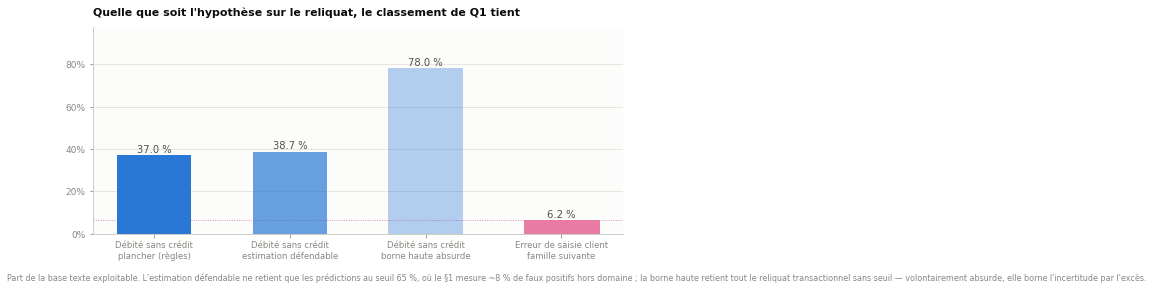

In [11]:
fig, ax = plt.subplots(figsize=(9.5, 3.8))
etiquettes = ["Débité sans crédit\nplancher (règles)",
              "Débité sans crédit\nestimation défendable",
              "Débité sans crédit\nborne haute absurde",
              "Erreur de saisie client\nfamille suivante"]
valeurs = bornes["pct_base"].to_numpy()
barres = ax.bar(etiquettes, valeurs, color=viz.SERIES[0], width=0.55)
for barre, alpha in zip(barres, [1.0, 0.7, 0.35, 1.0]):
    barre.set_alpha(alpha)
barres[3].set_color(viz.SERIES[4])
for b, v in zip(barres, valeurs):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.1f} %", ha="center",
            fontsize=10, color=viz.ENCRE["secondaire"])
ax.axhline(valeurs[3], color=viz.SERIES[4], linewidth=0.9, linestyle=":", zorder=0)
ax.set_ylim(0, max(valeurs) * 1.25)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=100, decimals=0))
ax.set_title("Quelle que soit l'hypothèse sur le reliquat, le classement de Q1 tient")
ax.tick_params(axis="x", labelsize=8.5)
ax.grid(axis="x", visible=False)
viz.annoter_source(
    fig,
    "Part de la base texte exploitable. L'estimation défendable ne retient que les prédictions au seuil 65 %, "
    "où le §1 mesure ~8 % de faux positifs hors domaine ; la borne haute retient tout le reliquat transactionnel "
    "sans seuil — volontairement absurde, elle borne l'incertitude par l'excès.",
)
viz.sauver(fig, "14_bornes_debit_non_credit")
plt.show()

**Lecture.** L'écart est d'un ordre de grandeur : même dans l'hypothèse
absurde, `debit_non_credit` reste plus de dix fois la famille suivante. La
question « faut-il classer le reliquat ? » n'a donc **pas d'enjeu
décisionnel** — elle ne peut changer ni le premier rang, ni l'attribution du
responsable (« Système, banque ↔ opérateur »), ni la priorisation qui en
découle. Le plancher de 37 % retenu au notebook 13 reste le chiffre à
présenter, précisément parce qu'il est le seul qui soit *mesuré*.

## 6. Conclusion et recommandation

**Ce que ce notebook établit :**

- La voie « classifieur supervisé entraîné sur les paires A↔B » est fermée,
  et pour une raison structurelle : l'espace d'étiquettes de B (six
  sous-motifs transactionnels) ne peut pas décrire un reliquat dont plus d'un
  tiers relève de `COMPTE`. Ce n'est pas un problème de volume
  d'entraînement — enrichir les paires ne le corrigerait pas.
- Le classifieur reste **valide dans son domaine** (~99 % de cohérence avec
  les règles). Ce qui est invalide, c'est son application au reliquat.
- Étendre les règles rapporte environ un huitième du reliquat : le rendement
  décroissant de `texte.py` est confirmé et chiffré.
- Le reliquat **ne peut pas renverser** la réponse à Q1 : `debit_non_credit`
  est première par un ordre de grandeur, plancher comme borne haute.

**Recommandation — ne pas chercher à fermer les 46 %, mais les requalifier.**
Le taux de non-classés doit continuer d'être présenté comme un **plancher**,
conformément à la règle déjà posée dans `texte.py`. En revanche, le §3
transforme ce reliquat en résultat : il existe un volume significatif de
sollicitations d'**accès au compte, de consultation de solde et de gestion de
compte** qui n'est aujourd'hui ni nommé, ni compté, ni attribué à un
responsable — alors que la taxonomie causale attribue un responsable à chacune
des six familles transactionnelles. C'est un angle mort de l'instrumentation,
plus actionnable pour la direction qu'une requalification fausse-précise.

**Si une classification apprise reste souhaitée**, la seule voie
méthodologiquement valide est une **annotation manuelle d'un échantillon
stratifié du reliquat lui-même** (`texte.echantillon_non_classes` fournit
déjà le tirage reproductible, et `chargement.sauver_audit` l'écriture hors
versionnement). Le problème à résoudre est l'espace d'étiquettes, pas
l'algorithme : aucun volume supplémentaire de paires A↔B ne le corrigera.